# 03 - Customer Segmentation (RFM Analysis)

## Objective

The objective of this notebook is to segment customers based on their purchasing behaviour using the RFM (Recency, Frequency, Monetary) framework.

RFM analysis is a widely used customer segmentation technique in marketing and customer relationship management (CRM). It evaluates customers based on:

- **Recency (R):** How recently a customer made a purchase.
- **Frequency (F):** How often a customer makes purchases.
- **Monetary (M):** How much a customer has spent.

The resulting customer segments help businesses identify their most valuable customers, customers at risk of churning, and opportunities for targeted marketing and customer retention strategies.

At the end of this notebook, each customer will be assigned to a meaningful business segment such as Champions, Loyal Customers, Potential Loyalists, At Risk, or Lost Customers.

# Step 1 — Import Libraries

In [57]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

# Step 2 — Load the Required Datasets

In [58]:
customers = pd.read_csv("../data/olist_customers_dataset.csv")

orders = pd.read_csv(
    "../data/olist_orders_dataset.csv",
    parse_dates=["order_purchase_timestamp"]
)

order_items = pd.read_csv("../data/olist_order_items_dataset.csv")

# Step 3 — Keep Only Delivered Orders

- As discussed in Notebook 02, customer purchasing behaviour should be based only on completed transactions.

In [59]:
orders = orders[orders["order_status"] == "delivered"].copy()

## Build Customer Transaction Dataset

Before calculating the RFM metrics, I will first create a customer transaction dataset by combining customer information, completed orders, and order values.

This consolidated dataset will provide the purchase date and monetary value for every completed customer order and will serve as the foundation for the RFM analysis.

# Step 4 — Create Order-Level Revenue

In [60]:
order_revenue = (
    order_items
    .groupby("order_id", as_index=False)["price"]
    .sum()
    .rename(columns={"price": "order_value"})
)

order_revenue.head()

,order_id,order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [61]:
print("Order revenue shape:", order_revenue.shape)
print("Unique order IDs:", order_revenue["order_id"].nunique())

Order revenue shape: (98666, 2)
Unique order IDs: 98666


### Order-Level Revenue

The `order_items` table may contain multiple rows for a single order because customers can purchase several products in one transaction.

To obtain one monetary value per transaction, product prices were aggregated by `order_id`. The resulting `order_revenue` table contains one row per order and represents the total product value associated with each transaction.

# Step 5 — Merge Revenue With Delivered Orders

In [62]:
orders_with_revenue = orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90


In [63]:
print("Delivered orders:", orders.shape[0])
print("Rows after revenue merge:", orders_with_revenue.shape[0])
print("Missing order values:", orders_with_revenue["order_value"].isna().sum())

Delivered orders: 96478
Rows after revenue merge: 96478
Missing order values: 0


### Merge Revenue With Completed Orders

The order-level revenue table was merged with the completed orders dataset using `order_id`.

A left join was used to preserve every delivered order while adding its corresponding monetary value. The row count and missing values were checked after the merge to ensure that the transaction data remained complete.

# Step 6 — Add the Unique Customer Identifier

In [64]:
customer_transactions = orders_with_revenue.merge(
    customers[["customer_id","customer_unique_id"]],
    on="customer_id",
    how="left"
)

customer_transactions.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_value,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,29.99,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,118.70,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,159.90,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,45.00,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,19.90,72632f0f9dd73dfee390c9b22eb56dd6


In [65]:
print("Rows before customer merge:", orders_with_revenue.shape[0])
print("Rows after customer merge:", customer_transactions.shape[0])

print(
    "Missing unique customer IDs:",
    customer_transactions["customer_unique_id"].isna().sum()
)

Rows before customer merge: 96478
Rows after customer merge: 96478
Missing unique customer IDs: 0


# Step 7 — Keep Only the Required RFM Columns

In [66]:
customer_transactions = customer_transactions[
    [
        "customer_unique_id",
        "order_id",
        "order_purchase_timestamp",
        "order_value"
    ]
].copy()

customer_transactions.head()

,customer_unique_id,order_id,order_purchase_timestamp,order_value
0,7c396fd4830fd04220f754e42b4e5bff,e481f51cbdc54678b7cc49136f2d6af7,2017-10-02 10:56:33,29.99
1,af07308b275d755c9edb36a90c618231,53cdb2fc8bc7dce0b6741e2150273451,2018-07-24 20:41:37,118.70
2,3a653a41f6f9fc3d2a113cf8398680e8,47770eb9100c2d0c44946d9cf07ec65d,2018-08-08 08:38:49,159.90
3,7c142cf63193a1473d2e66489a9ae977,949d5b44dbf5de918fe9c16f97b45f8a,2017-11-18 19:28:06,45.00
4,72632f0f9dd73dfee390c9b22eb56dd6,ad21c59c0840e6cb83a9ceb5573f8159,2018-02-13 21:18:39,19.90


In [67]:
customer_transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 96478 entries, 0 to 96477
Data columns (total 4 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   customer_unique_id        96478 non-null  str           
 1   order_id                  96478 non-null  str           
 2   order_purchase_timestamp  96478 non-null  datetime64[us]
 3   order_value               96478 non-null  float64       
dtypes: datetime64[us](1), float64(1), str(2)
memory usage: 2.9 MB


In [68]:
print("Transaction rows:", customer_transactions.shape[0])
print(
    "Unique customers:",
    customer_transactions["customer_unique_id"].nunique()
)
print(
    "Unique orders:",
    customer_transactions["order_id"].nunique()
)

Transaction rows: 96478
Unique customers: 93358
Unique orders: 96478


### Customer Transaction Dataset

Customer information was merged with the completed order data using `customer_id`.

The `customer_unique_id` field was retained because it identifies the same customer across multiple transactions, making it the appropriate identifier for customer-level analysis.

The final transaction dataset contains:

- Unique customer identifier
- Order identifier
- Purchase date
- Order value

Each row represents one completed customer order and will be used to calculate Recency, Frequency, and Monetary values.

# Step 8 — Determine the Analysis Date

- To calculate Recency, I need a reference point (also called the analysis date or snapshot date).
- Since the dataset is historical, I used one day after the latest purchase date as our reference point. This is standard practice in RFM analysis because it ensures every customer has a non-zero recency value.

In [69]:
# Find the latest purchase date
customer_transactions["order_purchase_timestamp"].max()

Timestamp('2018-08-29 15:00:37')

In [70]:
analysis_date = (
    customer_transactions["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print("Analysis Date:", analysis_date)

Analysis Date: 2018-08-30 15:00:37


## Define the Analysis Date

Recency is calculated as the number of days between a customer's most recent purchase and a reference date.

The analysis date is defined as one day after the latest purchase recorded in the dataset. Using a fixed reference date ensures that recency values are calculated consistently for all customers.

# Step 9 — Calculate the RFM Metrics

In [71]:
rfm = (
    customer_transactions
    .groupby("customer_unique_id")
    .agg(
        Recency=(
            "order_purchase_timestamp",
            lambda x: (analysis_date - x.max()).days
        ),
        Frequency=(
            "order_id",
            "nunique"
        ),
        Monetary=(
            "order_value",
            "sum"
        )
    )
    .reset_index()
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90
2,0000f46a3911fa3c0805444483337064,537,1,69.00
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00


# Step 10 — Explore the RFM Metrics

In [72]:
rfm.describe().round(2)

,Recency,Frequency,Monetary
count,93358.00,93358.00,93358.00
mean,237.94,1.03,141.62
std,152.59,0.21,215.69
min,1.00,1.00,0.85
25%,114.00,1.00,47.65
50%,219.00,1.00,89.73
75%,346.00,1.00,154.74
max,714.00,15.00,13440.00


## Explore the RFM Metrics

Before assigning RFM scores, it is important to understand the distribution of the Recency, Frequency, and Monetary metrics.

Descriptive statistics provide an overview of customer purchasing behaviour and help identify skewness, outliers, and variation within the data. These insights will guide the scoring process in later sections.

# Step 11 — Check for Missing Values

In [73]:
rfm.isnull().sum()

customer_unique_id    0
Recency               0
Frequency             0
Monetary              0
dtype: int64

# Step 12 — Verify the Dataset Shape

In [74]:
print("Rows:", rfm.shape[0])
print("Columns:", rfm.shape[1])

Rows: 93358
Columns: 4


### Interpretation

The descriptive statistics reveal distinct patterns in customer purchasing behaviour.

- Recency values range from 1 to 714 days, indicating that while some customers purchased recently, many have been inactive for extended periods.
- The Frequency metric shows that the majority of customers placed only one completed order, highlighting relatively low repeat purchasing behaviour.
- Monetary values are highly skewed, with a small number of customers contributing substantially more revenue than the average customer.

Overall, the dataset suggests opportunities to improve customer retention and engagement while identifying and rewarding high-value customers through targeted marketing strategies.

# Step 13 — Convert RFM Metrics into Scores

In [75]:
# Recency Score (lower recency = higher score)
rfm["R_Score"] = pd.qcut(
    rfm["Recency"],
    q=5,
    labels=[5, 4, 3, 2, 1]
)

# Frequency Score (higher frequency = higher score)
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
)

# Monetary Score (higher spending = higher score)
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"],
    q=5,
    labels=[1, 2, 3, 4, 5]
)

rfm.head()

,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5


## Assign RFM Scores

To standardize customer behaviour, each RFM metric is converted into a score ranging from 1 to 5 using quintiles.

- **Recency:** Lower values receive higher scores because recent customers are considered more engaged.
- **Frequency:** Higher purchase frequency receives higher scores.
- **Monetary:** Higher spending receives higher scores.

The Frequency metric contains many tied values, as most customers placed only one order. To enable quintile-based scoring, customer frequencies are ranked before applying the quantile calculation.

# Step 14 — Validate the Scores

In [76]:
rfm[["R_Score", "F_Score", "M_Score"]].describe()

,R_Score,F_Score,M_Score
count,93358,93358,93358
unique,5,5,5
top,5,1,2
freq,18728,18672,19437


# Step 15 — Create Business Segments

## 1. Create the RF Score

In [77]:
rfm["RF_Score"] = (
    rfm["R_Score"].astype(str)
    + rfm["F_Score"].astype(str)
)

rfm[
    ["R_Score", "F_Score", "RF_Score"]
].head()

,R_Score,F_Score,RF_Score
0,4,1,41
1,4,1,41
2,1,1,11
3,2,1,21
4,2,1,21


## 2. Add the Segment Mapping

In [78]:
segment_map = {
    # Recency score 5
    "55": "Champions",
    "54": "Champions",
    "53": "Potential Loyalists",
    "52": "Potential Loyalists",
    "51": "New Customers",

    # Recency score 4
    "45": "Loyal Customers",
    "44": "Loyal Customers",
    "43": "Potential Loyalists",
    "42": "Potential Loyalists",
    "41": "Promising",

    # Recency score 3
    "35": "Loyal Customers",
    "34": "Loyal Customers",
    "33": "Need Attention",
    "32": "Need Attention",
    "31": "About to Sleep",

    # Recency score 2
    "25": "At Risk",
    "24": "At Risk",
    "23": "At Risk",
    "22": "Hibernating",
    "21": "Hibernating",

    # Recency score 1
    "15": "Cannot Lose Them",
    "14": "Cannot Lose Them",
    "13": "Hibernating",
    "12": "Hibernating",
    "11": "Lost"
}

## 3. Assign the New Segments

In [79]:
rfm["Customer_Segment"] = (
    rfm["RF_Score"]
    .map(segment_map)
)

print(
    "Missing segments:",
    rfm["Customer_Segment"].isna().sum()
)

rfm.head()

Missing segments: 0


,customer_unique_id,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RF_Score,Customer_Segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,129.90,4,1,4,41,Promising
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,18.90,4,1,1,41,Promising
2,0000f46a3911fa3c0805444483337064,537,1,69.00,1,1,2,11,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,25.99,2,1,1,21,Hibernating
4,0004aac84e0df4da2b147fca70cf8255,288,1,180.00,2,1,5,21,Hibernating


## 4. Check the New Segment Counts

In [80]:
rfm["Customer_Segment"].value_counts()

Customer_Segment
Loyal Customers        15005
Potential Loyalists    14993
Hibernating            14863
At Risk                11150
Champions               7535
Need Attention          7420
Cannot Lose Them        7376
Lost                    3827
Promising               3759
New Customers           3720
About to Sleep          3710
Name: count, dtype: int64

## Customer Segmentation Using RF Scores

Customer segments are assigned using a combination of Recency and Frequency scores.

Recency represents how recently a customer purchased, while Frequency reflects repeat purchasing behaviour. Monetary value is retained as a separate measure for evaluating the financial contribution of each segment.

This approach allows customers to be grouped according to their current engagement and loyalty while revenue is analysed separately.

# Step 16 — RFM Analysis and Visualization

## 1 – Customer Distribution

In [81]:
segment_summary = (
    rfm["Customer_Segment"]
    .value_counts()
    .reset_index()
)

segment_summary.columns = [
    "Customer_Segment",
    "Customer_Count"
]

segment_summary["Percentage"] = (
    segment_summary["Customer_Count"]
    / segment_summary["Customer_Count"].sum()
    * 100
).round(2)

segment_summary

,Customer_Segment,Customer_Count,Percentage
0,Loyal Customers,15005,16.07
1,Potential Loyalists,14993,16.06
2,Hibernating,14863,15.92
3,At Risk,11150,11.94
4,Champions,7535,8.07
5,Need Attention,7420,7.95
6,Cannot Lose Them,7376,7.90
7,Lost,3827,4.10
8,Promising,3759,4.03
9,New Customers,3720,3.98


In [82]:
segment_order = [
    "Champions",
    "Loyal Customers",
    "Potential Loyalists",
    "New Customers",
    "Promising",
    "Need Attention",
    "About to Sleep",
    "At Risk",
    "Cannot Lose Them",
    "Hibernating",
    "Lost"
]

segment_summary["Customer_Segment"] = pd.Categorical(
    segment_summary["Customer_Segment"],
    categories=segment_order,
    ordered=True
)

segment_summary = segment_summary.sort_values("Customer_Segment")

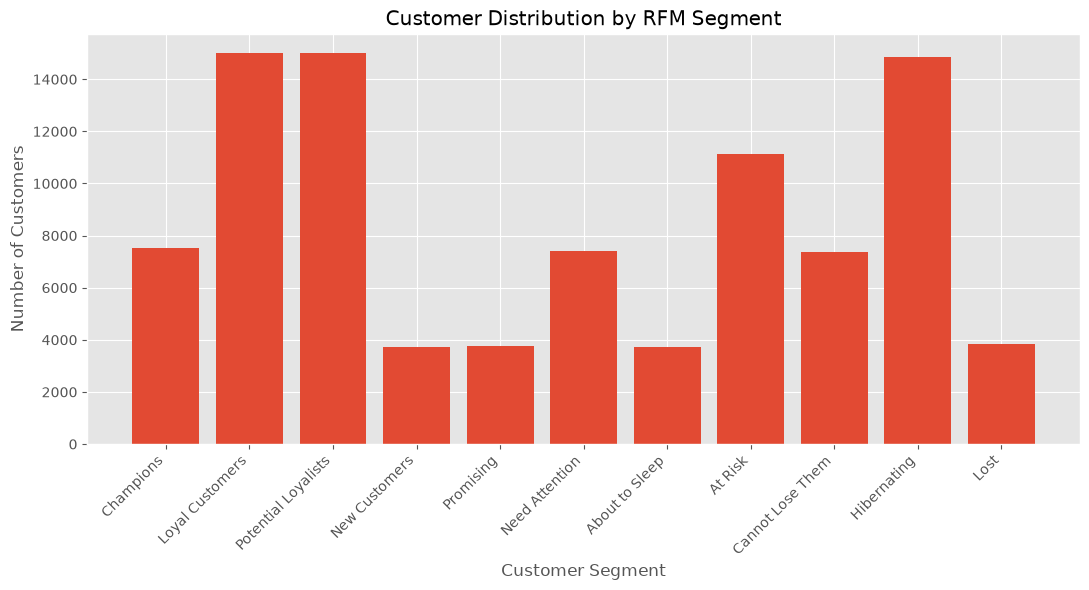

In [83]:
plt.figure(figsize=(11,6))

plt.bar(
    segment_summary["Customer_Segment"],
    segment_summary["Customer_Count"]
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

## 2 – Revenue by Segment

In [84]:
segment_revenue = (
    rfm
    .groupby("Customer_Segment", as_index=False)
    .agg(
        Total_Revenue=("Monetary", "sum"),
        Average_Revenue=("Monetary", "mean")
    )
)

segment_revenue["Revenue_Share"] = (
    segment_revenue["Total_Revenue"]
    / segment_revenue["Total_Revenue"].sum()
    * 100
).round(2)

segment_revenue = segment_revenue.sort_values(
    "Total_Revenue",
    ascending=False
)

segment_revenue

,Customer_Segment,Total_Revenue,Average_Revenue,Revenue_Share
6,Loyal Customers,2183605.24,145.525174,16.52
9,Potential Loyalists,2113031.95,140.934566,15.98
4,Hibernating,2079634.71,139.920252,15.73
1,At Risk,1621919.44,145.463627,12.27
3,Champions,1125129.90,149.320491,8.51
2,Cannot Lose Them,1069923.11,145.054652,8.09
7,Need Attention,962677.47,129.740899,7.28
10,Promising,537046.65,142.869553,4.06
5,Lost,532320.43,139.096010,4.03
8,New Customers,504033.24,135.492806,3.81


In [85]:
segment_revenue["Customer_Segment"] = pd.Categorical(
    segment_revenue["Customer_Segment"],
    categories=segment_order,
    ordered=True
)

segment_revenue = segment_revenue.sort_values("Customer_Segment")

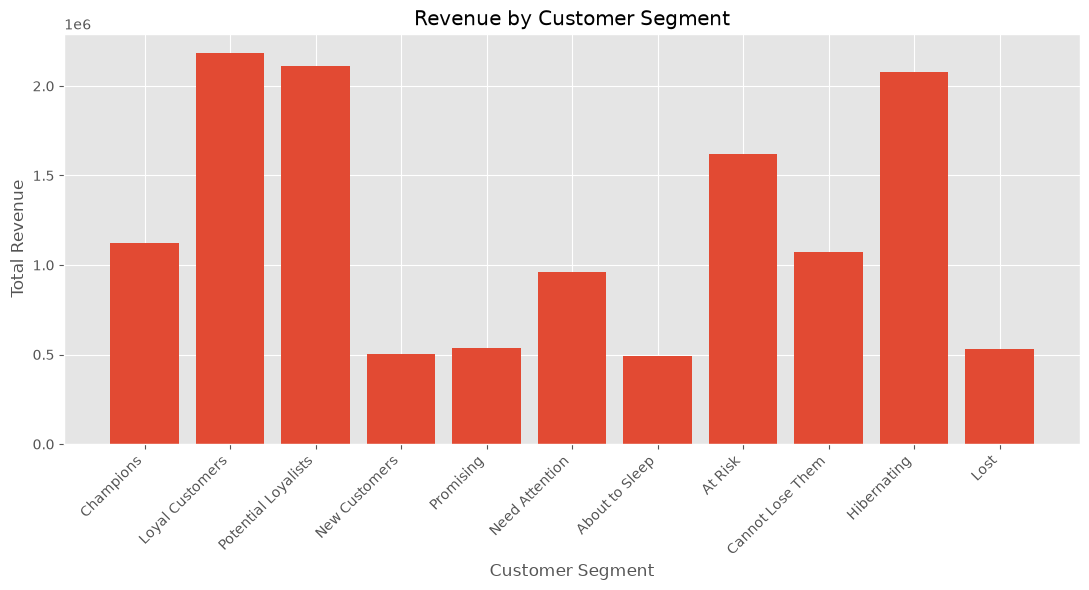

In [86]:
plt.figure(figsize=(11,6))

plt.bar(
    segment_revenue["Customer_Segment"],
    segment_revenue["Total_Revenue"]
)

plt.title("Revenue by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [87]:
segment_analysis = (
    segment_summary.merge(
        segment_revenue,
        on="Customer_Segment"
    )
)

segment_analysis

,Customer_Segment,Customer_Count,Percentage,Total_Revenue,Average_Revenue,Revenue_Share
0,Champions,7535,8.07,1125129.90,149.320491,8.51
1,Loyal Customers,15005,16.07,2183605.24,145.525174,16.52
2,Potential Loyalists,14993,16.06,2113031.95,140.934566,15.98
3,New Customers,3720,3.98,504033.24,135.492806,3.81
4,Promising,3759,4.03,537046.65,142.869553,4.06
5,Need Attention,7420,7.95,962677.47,129.740899,7.28
6,About to Sleep,3710,3.97,492175.97,132.661987,3.72
7,At Risk,11150,11.94,1621919.44,145.463627,12.27
8,Cannot Lose Them,7376,7.90,1069923.11,145.054652,8.09
9,Hibernating,14863,15.92,2079634.71,139.920252,15.73


# Summary

This notebook applied the **Recency, Frequency, Monetary (RFM)** framework to segment customers based on their purchasing behaviour. By analysing customer engagement, purchase frequency, and spending patterns, meaningful customer groups were identified to support targeted marketing and retention strategies.

## Key Findings

- Customers were successfully segmented into eleven business-oriented groups using their Recency and Frequency scores.
- **Loyal Customers** represent the largest customer segment (16.07%) and contribute the highest share of total revenue (16.52%), making them a key driver of overall business performance.
- **Potential Loyalists** account for 16.06% of customers and generate 15.98% of total revenue, representing an excellent opportunity for long-term customer retention.
- **Champions** represent only 8.07% of customers but generate the highest average revenue per customer, highlighting their strategic importance despite their relatively small size.
- **At Risk**, **Cannot Lose Them**, and **Hibernating** customers together account for a significant proportion of both customers and revenue, indicating considerable opportunities for customer reactivation.
- The relatively small differences in average revenue across segments suggest that business growth is driven more by customer engagement and repeat purchasing behaviour than by substantially higher spending per order.

## Business Interpretation

The RFM analysis demonstrates that customers are at different stages of their lifecycle and should not be treated equally.

Highly engaged customers such as **Champions** and **Loyal Customers** should be retained through loyalty programmes and personalised experiences. **Potential Loyalists**, **New Customers**, and **Promising** customers represent opportunities to encourage repeat purchases and increase long-term customer value. Customers in the **Need Attention**, **At Risk**, and **Cannot Lose Them** segments should be prioritised for retention campaigns before they become inactive. Finally, **Hibernating** and **Lost** customers should be evaluated through cost-effective reactivation strategies.

Overall, the analysis shows that personalised customer engagement strategies are likely to be more effective than a one-size-fits-all marketing approach.

## Recommended Business Actions

| Customer Segment | Characteristics | Recommended Business Action |
|------------------|-----------------|-----------------------------|
| **Champions** | Highly engaged, frequent purchasers with the highest average customer value. | Reward with loyalty programmes, exclusive offers, early product access, and referral incentives. |
| **Loyal Customers** | Consistent purchasers and the largest contributor to overall revenue. | Maintain engagement through personalised recommendations, cross-selling, and loyalty rewards. |
| **Potential Loyalists** | Recently active customers showing strong purchasing potential. | Encourage additional purchases using personalised promotions and targeted email campaigns. |
| **New Customers** | Recently acquired customers with limited purchase history. | Deliver onboarding experiences, recommend popular products, and encourage a second purchase through introductory offers. |
| **Promising** | Newer customers beginning to engage with the business. | Build purchasing habits through personalised marketing and loyalty incentives. |
| **Need Attention** | Customer engagement has started to decline. | Send reminder campaigns, personalised offers, and relevant product recommendations. |
| **About to Sleep** | Customers becoming inactive with declining engagement. | Launch win-back campaigns and limited-time promotional offers. |
| **At Risk** | Previously engaged customers who have not purchased recently. | Prioritise retention campaigns, personalised discounts, and customer feedback initiatives. |
| **Cannot Lose Them** | Historically valuable customers showing signs of disengagement. | Implement VIP retention campaigns with exclusive incentives and personalised outreach. |
| **Hibernating** | Long inactive period with limited recent engagement. | Use automated reactivation campaigns and evaluate long-term marketing effectiveness. |
| **Lost** | Customers with the longest inactivity period. | Apply low-cost reactivation campaigns and reduce marketing investment if they remain inactive. |

## Conclusion

The RFM framework provides a practical method for understanding customer behaviour beyond traditional sales analysis. By segmenting customers according to their engagement and purchasing patterns, businesses can prioritise marketing resources, improve customer retention, and maximise customer lifetime value.

Rather than treating every customer the same, the analysis demonstrates how tailored engagement strategies can improve business performance by rewarding loyal customers, nurturing promising customers, and reactivating customers at risk of churn.

The customer segments developed in this notebook provide the foundation for the next stage of the project, where **Customer Lifetime Value (CLV)** analysis will be used to quantify the long-term value of each customer and support more informed business decision-making.